<a href="https://colab.research.google.com/github/youssef-bendhaou/deep_learning/blob/cnn_cifar10_dataset/cnn_cifar10_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import tensorflow as tf
from tensorflow.keras import datasets , layers , models
import matplotlib.pyplot as plt
import numpy as np

In [13]:
(X_train , y_train),(X_test,y_test)=datasets.cifar10.load_data()

In [14]:
X_train.shape

(50000, 32, 32, 3)

In [15]:
X_test.shape

(10000, 32, 32, 3)

In [16]:
y_train.shape

(50000, 1)

In [17]:
y_train[:5]

array([[6],
       [9],
       [9],
       [4],
       [1]], dtype=uint8)

In [19]:
y_train = y_train.reshape(-1,)
y_train[:5]

array([6, 9, 9, 4, 1], dtype=uint8)

In [20]:
y_test = y_test.reshape(-1,)

In [21]:
classes = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

In [22]:
def plot_sample(X, y, index):
    plt.figure(figsize = (15,2))
    plt.imshow(X[index])
    plt.xlabel(classes[y[index]])

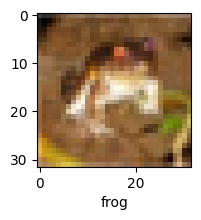

In [23]:
plot_sample(X_train, y_train, 0)

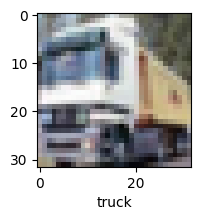

In [24]:
plot_sample(X_train, y_train, 1)

In [25]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [26]:
ann = models.Sequential([
        layers.Flatten(input_shape=(32,32,3)),
        layers.Dense(3000, activation='relu'),
        layers.Dense(1000, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

ann.compile(optimizer='SGD',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

ann.fit(X_train, y_train, epochs=5)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 148s 95ms/step - accuracy: 0.3561 - loss: 1.8120
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 124s 79ms/step - accuracy: 0.4280 - loss: 1.6231
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 139s 77ms/step - accuracy: 0.4574 - loss: 1.5412
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 119s 76ms/step - accuracy: 0.4775 - loss: 1.4833
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 126s 81ms/step - accuracy: 0.4981 - loss: 1.4319


In [27]:
from sklearn.metrics import confusion_matrix , classification_report
import numpy as np
y_pred = ann.predict(X_test)
y_pred_classes = [np.argmax(element) for element in y_pred]

print("Classification Report: \n", classification_report(y_test, y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step
Classification Report: 
               precision    recall  f1-score   support

           0       0.70      0.34      0.46      1000
           1       0.72      0.47      0.57      1000
           2       0.29      0.52      0.37      1000
           3       0.37      0.25      0.30      1000
           4       0.30      0.42      0.35      1000
           5       0.47      0.26      0.33      1000
           6       0.33      0.74      0.46      1000
           7       0.66      0.32      0.43      1000
           8       0.59      0.65      0.62      1000
           9       0.66      0.42      0.51      1000

    accuracy                           0.44     10000
   macro avg       0.51      0.44      0.44     10000
weighted avg       0.51      0.44      0.44     10000



In [28]:
cnn = models.Sequential([
    layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [29]:
cnn.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [30]:
cnn.fit(X_train, y_train, epochs=10)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 58s 36ms/step - accuracy: 0.4751 - loss: 1.4642
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 58s 37ms/step - accuracy: 0.6089 - loss: 1.1204
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 36ms/step - accuracy: 0.6556 - loss: 0.9917
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 36ms/step - accuracy: 0.6876 - loss: 0.9002
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 58s 37ms/step - accuracy: 0.7106 - loss: 0.8310
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 57s 36ms/step - accuracy: 0.7324 - loss: 0.7694
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 58s 37ms/step - accuracy: 0.7488 - loss: 0.7224
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 56s 36ms/step - accuracy: 0.7631 - loss: 0.6779
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 57s 37ms/step - accuracy: 0.7757 - loss: 0.6387
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 58s 37ms/step - accuracy: 0.7911 - loss: 0.5934


In [31]:
cnn.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.7035 - loss: 0.9304


[0.9304353594779968, 0.703499972820282]

In [32]:
y_pred = cnn.predict(X_test)
y_pred[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


array([[8.78305582e-05, 1.03132140e-06, 4.60019987e-03, 8.39989543e-01,
        2.23481038e-04, 1.45458862e-01, 7.62338843e-03, 2.01046328e-06,
        1.97438407e-03, 3.93103110e-05],
       [7.55160600e-02, 8.97463644e-04, 4.44965309e-07, 6.30333830e-07,
        4.20628288e-09, 2.74628150e-07, 1.90568912e-07, 2.13735629e-09,
        9.23533201e-01, 5.17836779e-05],
       [1.30204514e-01, 7.13815466e-02, 9.23537940e-04, 2.24598520e-03,
        9.84614016e-05, 1.75661135e-05, 1.09867709e-04, 7.37499067e-06,
        7.84435511e-01, 1.05755329e-02],
       [9.95245039e-01, 1.25859294e-03, 1.40441675e-03, 3.27362155e-04,
        5.01523209e-05, 4.52562404e-07, 5.41107852e-07, 2.56918756e-05,
        1.65752077e-03, 3.01828313e-05],
       [6.59065972e-06, 1.05606305e-05, 6.58672396e-03, 1.18825687e-02,
        2.52517462e-01, 3.66142922e-04, 7.28623092e-01, 5.96281097e-07,
        5.66028257e-06, 5.81496977e-07]], dtype=float32)

In [33]:
y_classes = [np.argmax(element) for element in y_pred]
y_classes[:5]

[np.int64(3), np.int64(8), np.int64(8), np.int64(0), np.int64(6)]

In [34]:
y_test[:5]

array([3, 8, 8, 0, 6], dtype=uint8)

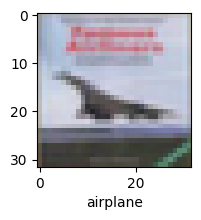

In [35]:
plot_sample(X_test, y_test,3)

In [36]:
classes[y_classes[3]]

'airplane'

In [37]:
classes[y_classes[3]]

'airplane'